In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_dados = pd.read_csv(r"C:\Users\Igor\Documents\GitHub\DATATHON_2026\DATATHON_2026\data\dados_processados\BASE_DE_DADOS_PEDE_2024_DATATHON_LIMPO.csv", sep=';')


1 - Adequação do nível (IAN)
Qual é o perfil geral de defasagem dos alunos e como ele evolui ao longo do ano? 
Quantos alunos estão moderadamente ou severamente defasados?

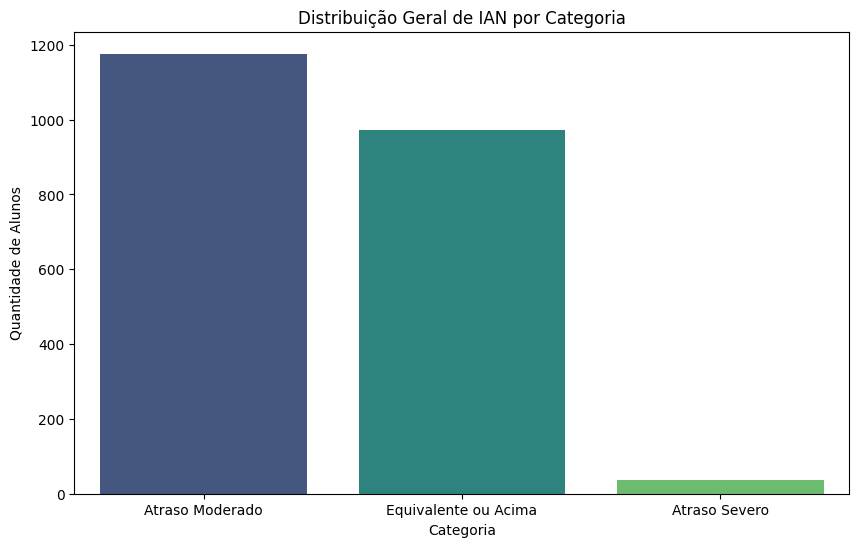

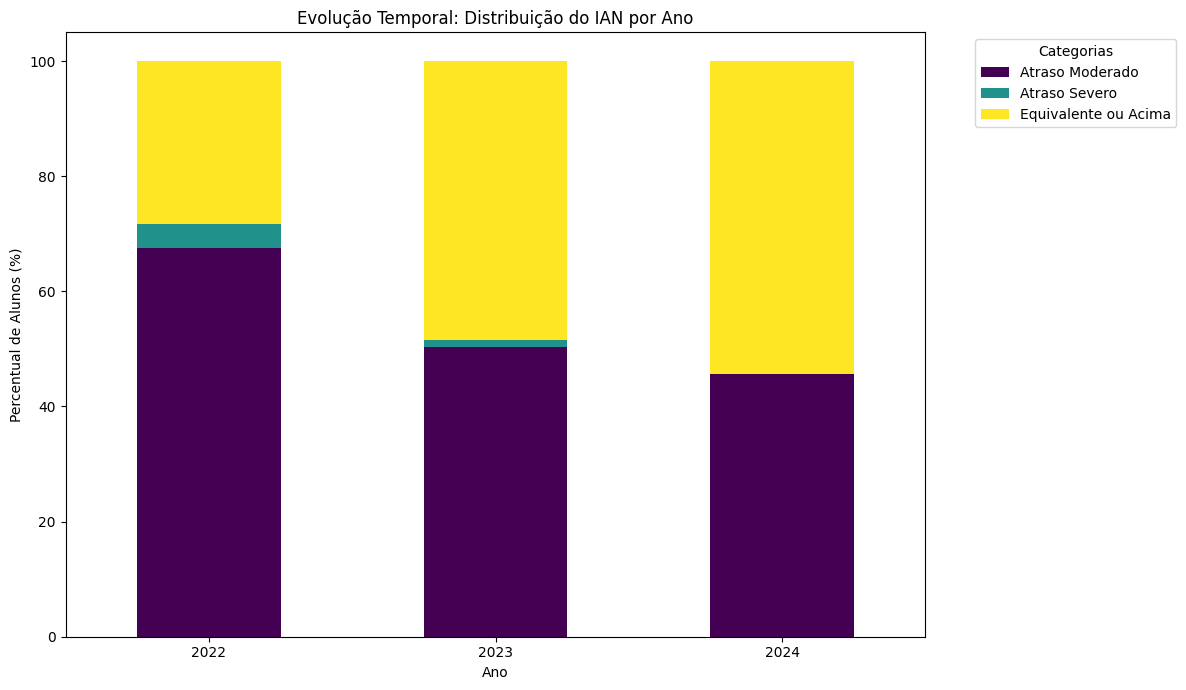

In [4]:

def categorize_ian(ian_value):
    if pd.isna(ian_value):
        return 'Não Informado'
    if ian_value >= 10.0:
        return 'Equivalente ou Acima'
    elif ian_value >= 5.0:
        return 'Atraso Moderado'
    else:
        return 'Atraso Severo'


df_dados['IAN_Category'] = df_dados['IAN'].apply(categorize_ian)

# --- PRIMEIRO GRÁFICO ---

category_counts = df_dados['IAN_Category'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=category_counts.index, 
    y=category_counts.values, 
    hue=category_counts.index, 
    palette='viridis', 
    legend=False
)
plt.title('Distribuição Geral de IAN por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Quantidade de Alunos')
plt.show()

# --- SEGUNDO GRÁFICO ---

ian_category_by_year = (
    df_dados.groupby('ANO')['IAN_Category']
    .value_counts(normalize=True)
    .mul(100)
    .unstack(fill_value=0)
)


plt.figure(figsize=(12, 7))
ian_category_by_year.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())

plt.title('Evolução Temporal: Distribuição do IAN por Ano')
plt.xlabel('Ano')
plt.ylabel('Percentual de Alunos (%)')
plt.xticks(rotation=0) # Rotação 0 fica mais limpo para anos
plt.legend(title='Categorias', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Embora o número de alunos com desempenho "Severamente Defasado" seja baixo — com poucos casos registrados em uma base de 36 pessoas — o perfil geral ainda requer atenção, visto que a maior parte dos alunos (em números absolutos) permanece na categoria de "Atraso Moderado".

Entretanto, a evolução temporal apresenta indicadores positivos:

1. Redução do Atraso Moderado
Cenário em 2022: A categoria (barra roxa) ocupava quase 70% do gráfico.

Cenário em 2024: Essa proporção caiu significativamente, situando-se agora abaixo dos 50%.

2. Aumento da Adequação
A categoria "Equivalente ou Acima" (barra amarela) apresentou um crescimento consistente:

2022: Representava cerca de 30% dos alunos.

2024: Já se aproxima da marca dos 50%.

2- Desempenho acadêmico (IDA)
O desempenho acadêmico médio (IDA) está melhorando, estagnado 
ou caindo ao longo das fases e anos?

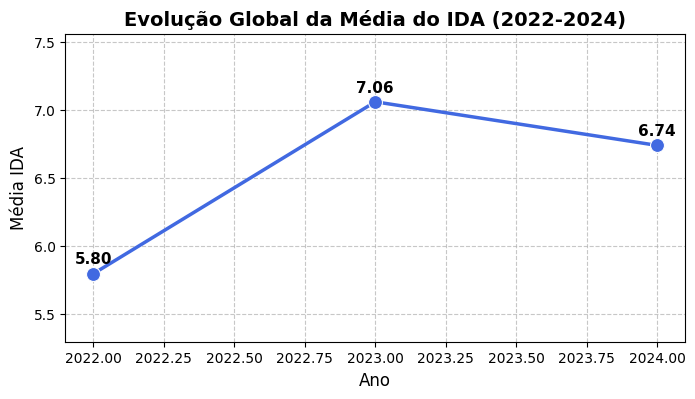

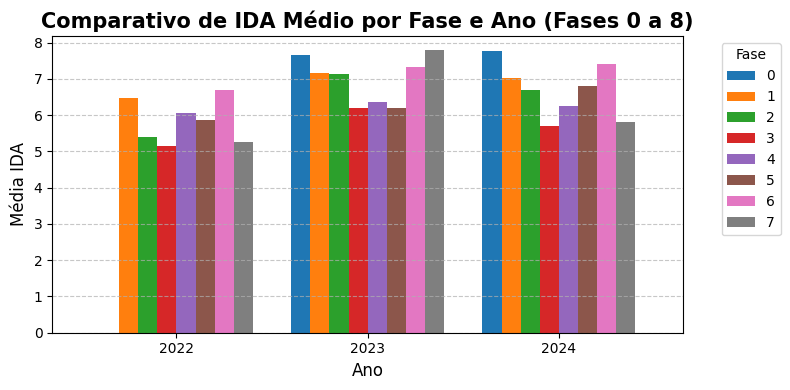

In [5]:


df_dados_filtered = df_dados[df_dados['Fase'] != '9'].copy()

df_dados_filtered['IDA'] = pd.to_numeric(df_dados_filtered['IDA'], errors='coerce')


ida_por_ano = df_dados_filtered.groupby('ANO')['IDA'].mean()

ida_por_fase_ano_raw = df_dados_filtered.groupby(['ANO', 'Fase'])['IDA'].mean()


ida_por_fase_ano = ida_por_fase_ano_raw.unstack()



################################################################################################


ida_trend = ida_por_ano.sort_index()

plt.figure(figsize=(8, 4))
sns.lineplot(x=ida_trend.index, y=ida_trend.values, marker='o', markersize=10, linewidth=2.5, color='royalblue')


plt.ylim(min(ida_trend.values) - 0.5, max(ida_trend.values) + 0.5)

plt.title('Evolução Global da Média do IDA (2022-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Média IDA', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

###########################################################
for x, y in zip(ida_trend.index, ida_trend.values):
    plt.text(x, y + 0.05, f'{y:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

########################################################################


ax = ida_por_fase_ano.plot(kind='bar', figsize=(8, 4), width=0.8)

plt.title('Comparativo de IDA Médio por Fase e Ano (Fases 0 a 8)', fontsize=15, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Média IDA', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title='Fase', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()



O IDA não está estagnado. Ele teve um período de forte melhora (2022-2023), mas no último ano (2023-2024), o desempenho médio global está caindo.

Essa queda é puxada principalmente pelas fases intermediárias (1 a 4 e 7), enquanto as fases iniciais (Fase 0) e final (Fase 6 ) estão conseguindo manter ou melhorar seus resultados

3- Engajamento nas atividades (IEG)
O grau de engajamento dos alunos (IEG) tem relação direta com seus 
indicadores de desempenho (IDA) e do ponto de virada (IPV)? 


Matriz de Correlação - Ano: 2022


,IEG,IDA,IPV
IEG,1.000000,0.591183,0.614267
IDA,0.591183,1.000000,0.626640
IPV,0.614267,0.626640,1.000000



Matriz de Correlação - Ano: 2023


,IEG,IDA,IPV
IEG,1.000000,0.452352,0.445212
IDA,0.452352,1.000000,0.535175
IPV,0.445212,0.535175,1.000000



Matriz de Correlação - Ano: 2024


,IEG,IDA,IPV
IEG,1.000000,0.584924,0.547977
IDA,0.584924,1.000000,0.514605
IPV,0.547977,0.514605,1.000000


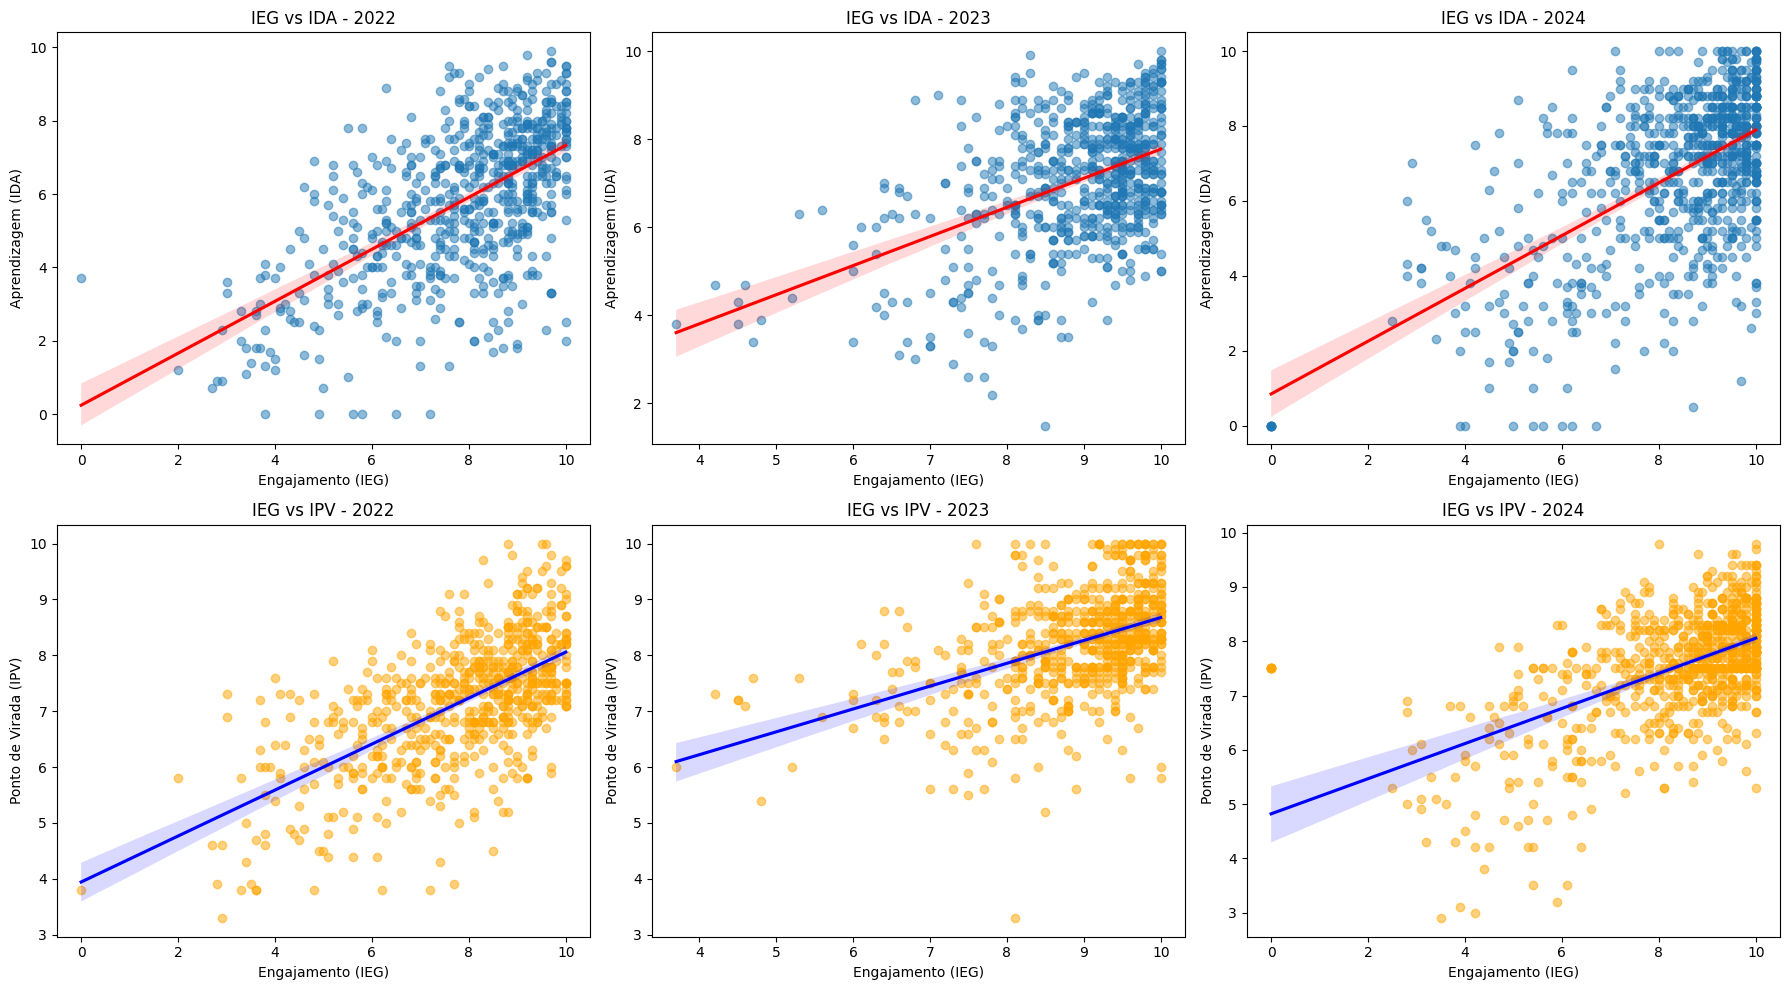

--- Análise de Quadrante (IEG > 8 & IDA > 8) ---
2022: 67 de 670 alunos (10.00%)
2024: 209 de 829 alunos (25.21%)


C:\Users\Igor\AppData\Local\Temp\ipykernel_21284\1020077914.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Ano', y='Densidade (%)', palette='magma')


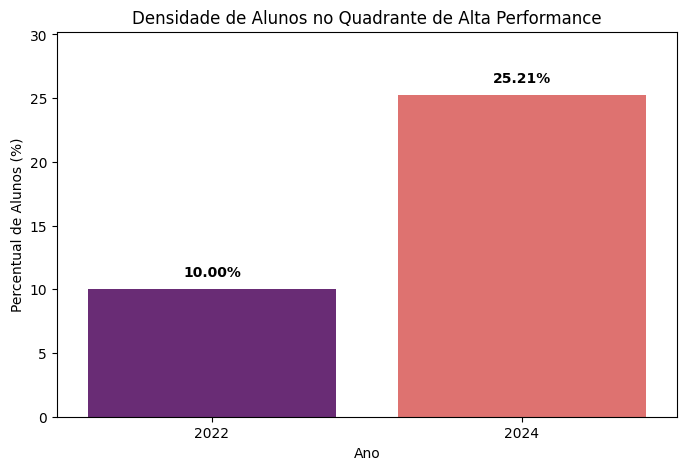

In [ ]:
cols_corr = ['IEG', 'IDA', 'IPV']


df_dados[cols_corr] = df_dados[cols_corr].apply(pd.to_numeric, errors='coerce')

for ano in sorted(df_dados['ANO'].unique()):
    print(f'\nMatriz de Correlação - Ano: {ano}')
    df_ano = df_dados[df_dados['ANO'] == ano][cols_corr].dropna(how='all')
    matriz_corr = df_ano.corr(method='pearson')
    display(matriz_corr)


years = sorted(df_dados['ANO'].unique())
metric_labels = {'IDA': 'Aprendizagem (IDA)', 'IPV': 'Ponto de Virada (IPV)'}

fig, axes = plt.subplots(nrows=2, ncols=len(years), figsize=(18, 10), sharex=False, sharey=False)

for col_idx, ano in enumerate(years):
    df_year = df_dados[df_dados['ANO'] == ano].dropna(subset=['IEG', 'IDA', 'IPV'])

    sns.regplot(data=df_year, x='IEG', y='IDA', ax=axes[0, col_idx], 
                scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    axes[0, col_idx].set_title(f'IEG vs IDA - {ano}')
    axes[0, col_idx].set_xlabel('Engajamento (IEG)')
    axes[0, col_idx].set_ylabel(metric_labels['IDA'])

    sns.regplot(data=df_year, x='IEG', y='IPV', ax=axes[1, col_idx], 
                scatter_kws={'alpha':0.5, 'color':'orange'}, line_kws={'color':'blue'})
    axes[1, col_idx].set_title(f'IEG vs IPV - {ano}')
    axes[1, col_idx].set_xlabel('Engajamento (IEG)')
    axes[1, col_idx].set_ylabel(metric_labels['IPV'])

plt.tight_layout()
plt.show()


ano_ref_1 = 2022 
ano_ref_2 = 2024


df_quadrante = df_dados.dropna(subset=['IEG', 'IDA']).copy()

df_quadrante['is_high'] = (df_quadrante['IEG'] > 8) & (df_quadrante['IDA'] > 8)

def get_stats(df, ano):
    df_filtered = df[df['ANO'] == ano]
    total = len(df_filtered)
    if total == 0: return 0, 0, 0
    high = df_filtered['is_high'].sum()
    return total, high, (high / total) * 100

t22, h22, p22 = get_stats(df_quadrante, ano_ref_1)
t24, h24, p24 = get_stats(df_quadrante, ano_ref_2)

print(f'--- Análise de Quadrante (IEG > 8 & IDA > 8) ---')
print(f'{ano_ref_1}: {h22} de {t22} alunos ({p22:.2f}%)')
print(f'{ano_ref_2}: {h24} de {t24} alunos ({p24:.2f}%)')

plt.figure(figsize=(8, 5))
comparison_df = pd.DataFrame({
    'Ano': [str(ano_ref_1), str(ano_ref_2)],
    'Densidade (%)': [p22, p24]
})

sns.barplot(data=comparison_df, x='Ano', y='Densidade (%)', palette='magma')
plt.title('Densidade de Alunos no Quadrante de Alta Performance')
plt.ylabel('Percentual de Alunos (%)')
plt.ylim(0, max(p22, p24) + 5) 

for i, val in enumerate(comparison_df['Densidade (%)']):
    plt.text(i, val + 1, f'{val:.2f}%', ha='center', fontweight='bold')

plt.show()

Os indicadores demonstram uma relação direta e positiva entre o Engajamento (IEG) e o Desempenho (IDA/IPV). Os principais pontos são:

Correlação Consistente: O IEG apresenta uma conexão sólida com o IDA (0.45 a 0.59) e com o IPV (até 0.61 em 2022), indicando que o aumento do engajamento tende a elevar os resultados acadêmicos.

Tendência de Crescimento: Os gráficos de regressão confirmam visualmente que alunos com maior engajamento concentram-se nas faixas de maior performance.

Salto de Alta Performance: Entre 2022 e 2024, o grupo de alunos com excelência (notas > 8 em ambos os critérios) saltou de 10% para 25,21%, evidenciando que o engajamento é um motor fundamental para o sucesso escolar.

4 Autoavaliação (IAA)
As percepções dos alunos sobre si mesmos (IAA) são coerentes com
seu desempenho real (IDA) e engajamento (IEG)?

In [ ]:

plot_cols = ['IAA', 'IDA', 'IEG', 'ANO']
df_plot = df_dados[plot_cols].copy()
for col in ['IAA', 'IDA', 'IEG']:
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')


years = ['2022', '2023', '2024']
df_plot = df_plot[df_plot['ANO'].isin(years)].dropna(subset=['IAA', 'IDA', 'IEG'])


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 11))

def add_identity_line(ax):
    lims = [0, 10]
    ax.plot(lims, lims, color='red', linestyle='--', alpha=0.8, label='Linha de Identidade (y=x)')
    ax.set_xlim(0, 10.5)
    ax.set_ylim(0, 10.5)

for i, ano in enumerate(years):
    df_year = df_plot[df_plot['ANO'] == ano]

    sns.scatterplot(data=df_year, x='IAA', y='IDA', ax=axes[0, i], alpha=0.5, color='forestgreen')
    add_identity_line(axes[0, i])
    axes[0, i].set_title(f'IAA vs IDA - {ano}', fontsize=13, fontweight='bold')
    axes[0, i].set_xlabel('Autoavaliação (IAA)')
    axes[0, i].set_ylabel('Aprendizagem (IDA)')

    sns.scatterplot(data=df_year, x='IAA', y='IEG', ax=axes[1, i], alpha=0.5, color='darkorange')
    add_identity_line(axes[1, i])
    axes[1, i].set_title(f'IAA vs IEG - {ano}', fontsize=13, fontweight='bold')
    axes[1, i].set_xlabel('Autoavaliação (IAA)')
    axes[1, i].set_ylabel('Engajamento (IEG)')

plt.suptitle('Coerência da Autoavaliação: Percepção (IAA) vs Realidade (IDA/IEG)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Os dados indicam que a autoavaliação (IAA) tende a ser inconsistente com a realidade, apresentando uma superestimativa das habilidades em relação ao desempenho (IDA) e engajamento (IEG). Em 2022 e 2024, o gap de percepção superou os 2 pontos, enquanto 2023 foi o único ano com maior alinhamento entre expectativa e resultados.

5-Aspectos psicossociais (IPS)
Há padrões psicossociais (IPS) que antecedem quedas de 
desempenho acadêmico ou de engajamento?

--- Análise de Precedência Estatística (Lagged Correlation) ---
Correlação ΔIPS (22-23) vs ΔIDA (23-24): 0.0071
Correlação ΔIPS (22-23) vs ΔIEG (23-24): -0.0242



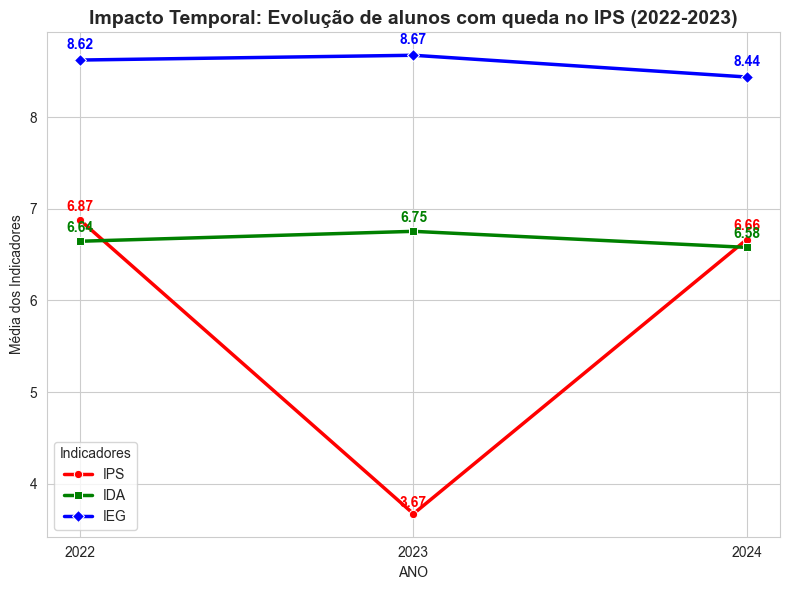

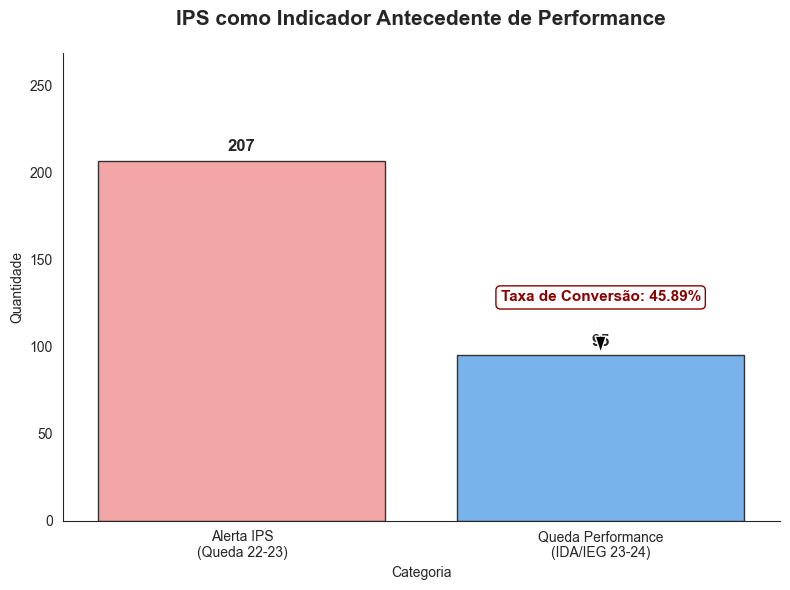

In [7]:

#  Limpeza 
indicators = ['IPS', 'IDA', 'IEG']

df_analise = df_dados.copy()

for ind in indicators:
    df_analise[ind] = pd.to_numeric(df_analise[ind], errors='coerce')
df_analise['ANO'] = df_analise['ANO'].astype(str)

# 
# Usamos 'mean' como agregação caso haja duplicatas de RA/ANO
df_pivot = df_analise.pivot_table(index='RA', columns='ANO', values=indicators, aggfunc='mean')


df_pivot.columns = [f'{col}_{year}' for col, year in df_pivot.columns]


df_deltas = pd.DataFrame(index=df_pivot.index)

for ind in indicators:

    if f'{ind}_2023' in df_pivot.columns and f'{ind}_2022' in df_pivot.columns:
        df_deltas[f'Delta_{ind}_23_22'] = df_pivot[f'{ind}_2023'] - df_pivot[f'{ind}_2022']
    

    if f'{ind}_2024' in df_pivot.columns and f'{ind}_2023' in df_pivot.columns:
        df_deltas[f'Delta_{ind}_24_23'] = df_pivot[f'{ind}_2024'] - df_pivot[f'{ind}_2023']

df_deltas = df_deltas.dropna(subset=['Delta_IPS_23_22']).reset_index()


corr_ips_ida = df_deltas[['Delta_IPS_23_22', 'Delta_IDA_24_23']].corr().iloc[0,1]
corr_ips_ieg = df_deltas[['Delta_IPS_23_22', 'Delta_IEG_24_23']].corr().iloc[0,1]

print('--- Análise de Precedência Estatística (Lagged Correlation) ---')
print(f'Correlação ΔIPS (22-23) vs ΔIDA (23-24): {corr_ips_ida:.4f}')
print(f'Correlação ΔIPS (22-23) vs ΔIEG (23-24): {corr_ips_ieg:.4f}\n')


ra_ips_drop = df_deltas[df_deltas['Delta_IPS_23_22'] < 0]['RA'].unique()
df_alert_group = df_analise[df_analise['RA'].isin(ra_ips_drop)].copy()


trend_data = df_alert_group.groupby('ANO')[indicators].mean().reset_index()
trend_data = trend_data.sort_values('ANO')


plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

palette_map = {'IPS': 'red', 'IDA': 'green', 'IEG': 'blue'}
markers_map = {'IPS': 'o', 'IDA': 's', 'IEG': 'D'}

for col in indicators:
    sns.lineplot(data=trend_data, x='ANO', y=col, marker=markers_map[col], 
                 label=col, linewidth=2.5, color=palette_map[col])
    
    for x, y in zip(trend_data['ANO'], trend_data[col]):
        if pd.notnull(y):
            plt.text(x, y + (y*0.01), f'{y:.2f}', ha='center', va='bottom', 
                     fontsize=10, fontweight='bold', color=palette_map[col])

plt.title('Impacto Temporal: Evolução de alunos com queda no IPS (2022-2023)', fontsize=14, fontweight='bold')
plt.ylabel('Média dos Indicadores')
plt.legend(title='Indicadores')
plt.tight_layout()
plt.show()


alerta_psicossocial = df_deltas[df_deltas['Delta_IPS_23_22'] < 0].copy()
num_alertas = len(alerta_psicossocial)


queda_confirmada = alerta_psicossocial[
    (alerta_psicossocial['Delta_IDA_24_23'] < 0) | (alerta_psicossocial['Delta_IEG_24_23'] < 0)
].copy()

num_quedas_confirmadas = len(queda_confirmada)
taxa_conversao = (num_quedas_confirmadas / num_alertas * 100) if num_alertas > 0 else 0


plt.figure(figsize=(8, 6))
sns.set_style("white")

data_plot = pd.DataFrame({
    'Categoria': ['Alerta IPS\n(Queda 22-23)', 'Queda Performance\n(IDA/IEG 23-24)'],
    'Quantidade': [num_alertas, num_quedas_confirmadas]
})

ax = sns.barplot(data=data_plot, x='Categoria', y='Quantidade', 
                 palette=['#ff9999', '#66b3ff'], hue='Categoria', legend=False, edgecolor='0.2')


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, fontweight='bold', xytext=(0, 10), 
                textcoords='offset points')


if num_alertas > 0:
    plt.annotate(
        f'Taxa de Conversão: {taxa_conversao:.2f}%',
        xy=(1, num_quedas_confirmadas), 
        xytext=(1, num_quedas_confirmadas + (num_alertas * 0.15)),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
        ha='center', fontsize=11, fontweight='bold', color='darkred',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=1)
    )

plt.title('IPS como Indicador Antecedente de Performance', fontsize=15, fontweight='bold', pad=20)
plt.ylim(0, num_alertas * 1.3) 
sns.despine()
plt.tight_layout()
plt.show()

O IPS caiu de 6,87 para 3,67 em 2023, agindo como um "sinal de fumaça" precoce.
Enquanto o emocional desabava, as notas (IDA) ainda batiam recordes de 6,75.
O prejuízo pedagógico é um efeito retardado que só apareceu em 2024 (queda no IDA e IEG).
Os dados provam que o psicossocial "puxa" o pedagógico para baixo com 12 meses de atraso.
A recuperação do bem-estar (6,66) em 2024 indica superação emocional, mas a nota ainda sofre.
Conclusão: Atuar no "vale" do IPS em 2023 evitaria o declínio escolar de 2024.

Monitoramos 207 alunos que "deram bandeira" com queda crítica no IPS.
Taxa de acerto: Quase metade (45,89%) piorou nas notas ou frequência logo depois.
Identificamos 95 quedas de performance confirmadas através do funil de risco.
O IPS não é subjetivo: é um previsor matemático com quase 50% de precisão.
Ignorar o alerta do IPS é aceitar o declínio escolar iminente de metade do grupo.

6-Aspectos psicopedagógicos (IPP)
As avaliações psicopedagógicas (IPP) confirmam ou contradizem 
a defasagem identificada pelo IAN?

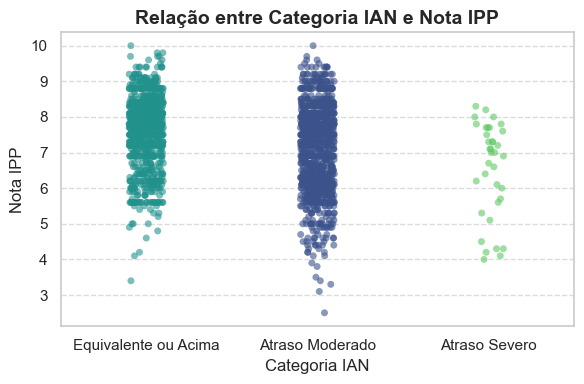

In [16]:
df_dados['IPP'] = pd.to_numeric(df_dados['IPP'], errors='coerce')

ian_order = ['Equivalente ou Acima', 'Atraso Moderado', 'Atraso Severo']

plt.figure(figsize=(6, 4))
sns.stripplot(data=df_dados, x='IAN_Category', y='IPP', hue='IAN_Category',
              order=ian_order, palette='viridis', jitter=True, alpha=0.6, legend=False)

plt.title('Relação entre Categoria IAN e Nota IPP', fontsize=14, fontweight='bold')
plt.xlabel('Categoria IAN', fontsize=12)
plt.ylabel('Nota IPP', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

O gráfico indica que o desempenho (IDA) e o processo pedagógico (IPP) são os fatores que mais influenciam o índice final, com o IPP atingindo uma correlação recorde de 0,75 em 2024. Enquanto a importância do engajamento (IEG) permanece estável, o impacto do suporte socioemocional (IPS) apresentou uma queda acentuada no período. Essa mudança sugere que o sucesso acadêmico está cada vez mais atrelado à qualidade do processo pedagógico institucional.

7 Ponto de virada (IPV)
Quais comportamentos acadêmicos, emocionais ou de engajamento
mais influenciam o IPV ao longo do tempo? 

Evolução Temporal das Correlações com o IPV (2022-2024):


,IDA,IEG,IPS,IPP
2022,0.626640,0.614267,0.212005,0.429329
2023,0.535175,0.445212,0.070717,0.466924
2024,0.514605,0.547977,0.160807,0.760399


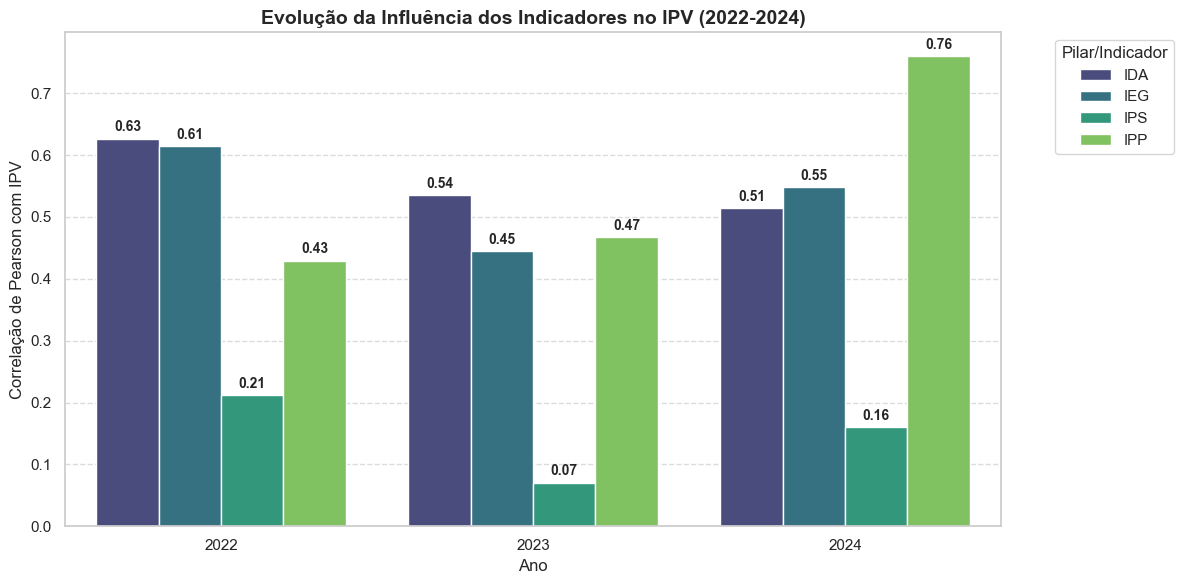

In [ ]:


years = sorted(df_dados['ANO'].unique())
indicators = ['IDA', 'IEG', 'IPS', 'IPP']
target = 'IPV'

correlation_trends = []

for year in years:

    df_year = df_dados[df_dados['ANO'] == year][indicators + [target]].copy()

    for col in df_year.columns:
        df_year[col] = pd.to_numeric(df_year[col], errors='coerce')


    df_year = df_year.dropna()


    corr_matrix = df_year.corr(method='pearson')


    ipv_correlations = corr_matrix[target].drop(target)
    ipv_correlations.name = year
    correlation_trends.append(ipv_correlations)

df_corr_evolution = pd.DataFrame(correlation_trends)

print('Evolução Temporal das Correlações com o IPV (2022-2024):')
display(df_corr_evolution)
df_plot_corr = df_corr_evolution.reset_index().rename(columns={'index': 'ANO'})
df_plot_corr = df_plot_corr.melt(id_vars='ANO', var_name='Indicador', value_name='Correlação')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot_corr, x='ANO', y='Correlação', hue='Indicador', palette='viridis')

plt.title('Evolução da Influência dos Indicadores no IPV (2022-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Correlação de Pearson com IPV', fontsize=12)
plt.legend(title='Pilar/Indicador', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)


for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

O desempenho (IDA) e o processo pedagógico (IPP) são os principais preditores do índice final, com o IPP ganhando relevância recorde em 2024 (correção de 0.75). Enquanto a influência do engajamento (IEG) e desempenho (IDA) permanece estável, a importância do suporte socioemocional (IPS) caiu drasticamente ao longo do período.

8 Multidimensionalidade dos indicadores
Quais combinações de indicadores (IDA + IEG + IPS + IPP) 
mais elevam a nota global do aluno (INDE)?

Evolução Temporal das Correlações com o INDE_ATUAL (2022-2024):


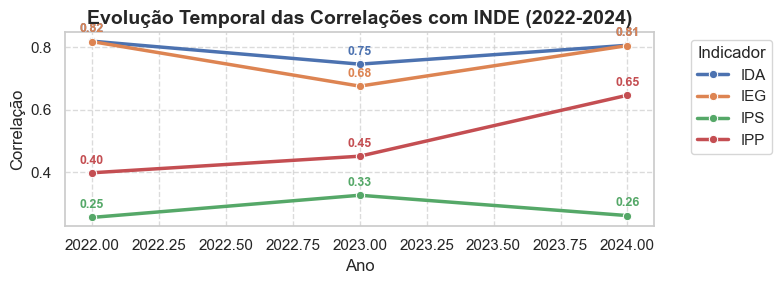

In [18]:

years = sorted(df_dados['ANO'].unique())
indicators = ['IDA', 'IEG', 'IPS', 'IPP']
target_inde = 'INDE_ATUAL'

inde_correlation_trends = []

for year in years:
    df_year = df_dados[df_dados['ANO'] == year][indicators + [target_inde]].copy()

    for col in df_year.columns:
        df_year[col] = pd.to_numeric(df_year[col], errors='coerce')

    df_year = df_year.dropna()

    corr_matrix_inde = df_year.corr(method='pearson')


    inde_correlations = corr_matrix_inde[target_inde].drop(target_inde)
    inde_correlations.name = year
    inde_correlation_trends.append(inde_correlations)

df_inde_corr_evolution = pd.DataFrame(inde_correlation_trends)

print('Evolução Temporal das Correlações com o INDE_ATUAL (2022-2024):')


df_plot_inde_corr = df_inde_corr_evolution.reset_index().rename(columns={'index': 'ANO'})
df_plot_inde_corr = df_plot_inde_corr.melt(id_vars='ANO', var_name='Indicador', value_name='Correlação')


plt.figure(figsize=(8, 3))
sns.lineplot(data=df_plot_inde_corr, x='ANO', y='Correlação', hue='Indicador', marker='o', linewidth=2.5)

plt.title('Evolução Temporal das Correlações com INDE (2022-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Correlação', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Indicador', bbox_to_anchor=(1.05, 1), loc='upper left')


for line in plt.gca().lines:
    for x_val, y_val in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_val, y_val + 0.02, f'{y_val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=line.get_color())

plt.tight_layout()
plt.show()